# Glassdoor Reviews Exploratory Analysis & Cleaning
Dataset: `data/raw/glass_reviews.csv`

This notebook covers data ingestion, schema cleaning, exploratory data analysis with reusable visualizations across all 7 rating categories, temporal analysis, and categorical profiling across 127 Glassdoor reviews.

### Cell 1: Data Ingestion & Initial Structure Inspection
**What we are exploring:**
- Loading the raw CSV file (`glass_reviews.csv`) into a pandas DataFrame.
- Auditing the raw schema: inspecting total column count (28 original columns) and header names.
- Checking null value counts for unpopulated columns (`review_advice`, `career_opportunities_rating`).
- Previewing the top 10 rows to inspect data formats, multi-line text fields, and potential anomalies.

In [1]:
import os
import pandas as pd

# Load raw dataset with fallback for working directory
file_path = 'data/raw/glass_reviews.csv'
if not os.path.exists(file_path):
    file_path = '../../data/raw/glass_reviews.csv'

df = pd.read_csv(file_path)

# 1. Print original columns before making any changes
print("=== Original Columns Count:", len(df.columns), "===")
print("Original Columns List:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\n=== Checking Missing Values in Target Unpopulated Columns ===")
print(df[['review_advice', 'career_opportunities_rating']].isnull().sum())

=== Original Columns Count: 28 ===
Original Columns List:
0: Unfair Workplace Practices and Lack of Growth Opportunities and Poor Work Conditions and Management Support:
1: rating_date
2: count_helpful
3: count_unhelpful
4: employee_length
5: employee_status
6: employee_type
7: flag_covid
8: flag_featured
9: flags_business_outlook
10: flags_ceo_approval
11: flags_recommend_frend
12: rating_culture_values
13: rating_diversity_inclusion
14: rating_overall
15: rating_work_life
16: summary
17: company_name
18: review_advice
19: career_opportunities_rating
20: employee_location
21: employee_job_title
22: advice_to_management
23: review_pros
24: review_cons
25: rating_compensation_benefits
26: rating_senior_leadership
27: rating_career_opportunities

=== Checking Missing Values in Target Unpopulated Columns ===
review_advice                  127
career_opportunities_rating    127
dtype: int64


In [2]:
# Disables truncation limits globally
pd.set_option('display.max_rows', None)     # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None) # Show full text inside cells

# Print your dataframe normally
print(df)


     Unfair Workplace Practices and Lack of Growth Opportunities and Poor Work Conditions and Management Support:  \
0                                                                                                               1   
1                                                                                                               2   
2                                                                                                               3   
3                                                                                                               4   
4                                                                                                               5   
5                                                                                                               6   
6                                                                                                               7   
7                                                               

### Cell 2: Header Repair & Index Column Renaming
**What we are exploring:**
- Repairing the corrupted first column header: in the raw export, column 0 was accidentally replaced with a review title string (`'Unfair Workplace Practices and Lack of Growth Opportunities...'`).
- Renaming this column to `'review_id'` to serve as a clean unique record identifier (1 to 127).
- Confirming the updated column list while retaining all original columns intact.

In [3]:
# Rename the corrupted first column header to 'review_id'
corrupted_header = df.columns[0]
print(f"Renaming corrupted header: '{corrupted_header}' -> 'review_id'")
df.rename(columns={corrupted_header: 'review_id'}, inplace=True)

# Print updated columns list (all 28 columns retained)
print("\n=== Updated Columns Count:", len(df.columns), "===")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Renaming corrupted header: 'Unfair Workplace Practices and Lack of Growth Opportunities and Poor Work Conditions and Management Support:' -> 'review_id'

=== Updated Columns Count: 28 ===
0: review_id
1: rating_date
2: count_helpful
3: count_unhelpful
4: employee_length
5: employee_status
6: employee_type
7: flag_covid
8: flag_featured
9: flags_business_outlook
10: flags_ceo_approval
11: flags_recommend_frend
12: rating_culture_values
13: rating_diversity_inclusion
14: rating_overall
15: rating_work_life
16: summary
17: company_name
18: review_advice
19: career_opportunities_rating
20: employee_location
21: employee_job_title
22: advice_to_management
23: review_pros
24: review_cons
25: rating_compensation_benefits
26: rating_senior_leadership
27: rating_career_opportunities


In [4]:
df.shape

(127, 28)

In [5]:
# Check how many values are missing in each column
df.isnull().sum().sort_values(ascending=False)

career_opportunities_rating     127
review_advice                   127
advice_to_management             90
flags_business_outlook           72
flags_ceo_approval               71
flags_recommend_frend            57
employee_location                 8
employee_job_title                5
employee_status                   2
summary                           1
review_id                         0
rating_senior_leadership          0
rating_compensation_benefits      0
review_cons                       0
review_pros                       0
company_name                      0
rating_overall                    0
rating_work_life                  0
rating_date                       0
rating_diversity_inclusion        0
rating_culture_values             0
flag_featured                     0
flag_covid                        0
employee_type                     0
employee_length                   0
count_unhelpful                   0
count_helpful                     0
rating_career_opportunities 

In [6]:
df['review_advice'].unique

<bound method Series.unique of 0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    NaN
12    NaN
13    NaN
14    NaN
15    NaN
16    NaN
17    NaN
18    NaN
19    NaN
20    NaN
21    NaN
22    NaN
23    NaN
24    NaN
25    NaN
26    NaN
27    NaN
28    NaN
29    NaN
30    NaN
31    NaN
32    NaN
33    NaN
34    NaN
35    NaN
36    NaN
37    NaN
38    NaN
39    NaN
40    NaN
41    NaN
42    NaN
43    NaN
44    NaN
45    NaN
46    NaN
47    NaN
48    NaN
49    NaN
50    NaN
51    NaN
52    NaN
53    NaN
54    NaN
55    NaN
56    NaN
57    NaN
58    NaN
59    NaN
60    NaN
61    NaN
62    NaN
63    NaN
64    NaN
65    NaN
66    NaN
67    NaN
68    NaN
69    NaN
70    NaN
71    NaN
72    NaN
73    NaN
74    NaN
75    NaN
76    NaN
77    NaN
78    NaN
79    NaN
80    NaN
81    NaN
82    NaN
83    NaN
84    NaN
85    NaN
86    NaN
87    NaN
88    NaN
89    NaN
90    NaN
91    NaN
92    NaN
93    NaN
94    NaN
95    NaN
96    NaN

In [7]:
# Get statistical summary of numeric columns
df.describe()

,review_id,count_helpful,count_unhelpful,employee_length,rating_culture_values,rating_diversity_inclusion,rating_overall,rating_work_life,review_advice,career_opportunities_rating,rating_compensation_benefits,rating_senior_leadership,rating_career_opportunities
count,127.000000,127.0,127.0,127.000000,127.000000,127.000000,127.000000,127.000000,0.0,0.0,127.000000,127.000000,127.000000
mean,64.000000,0.0,0.0,1.692913,2.188976,2.433071,3.448819,2.125984,NaN,NaN,2.551181,2.062992,2.275591
std,36.805797,0.0,0.0,2.335074,1.962879,2.087721,1.258045,1.881371,NaN,NaN,2.014663,1.897149,1.909364
min,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000
25%,32.500000,0.0,0.0,0.000000,0.000000,0.000000,3.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000
50%,64.000000,0.0,0.0,1.000000,2.000000,3.000000,4.000000,2.000000,NaN,NaN,3.000000,2.000000,3.000000
75%,95.500000,0.0,0.0,2.000000,4.000000,5.000000,4.000000,4.000000,NaN,NaN,4.000000,4.000000,4.000000
max,127.000000,0.0,0.0,20.000000,5.000000,5.000000,5.000000,5.000000,NaN,NaN,5.000000,5.000000,5.000000


### Cell 3: Verification of Cleaned DataFrame
**What we are exploring:**
- Inspecting `df.head()` to visually verify that `review_id` is properly indexed.
- Verifying `df.columns` to confirm all 28 feature names are correctly accessible for downstream analysis.

In [8]:
# Display columns

df.columns

Index(['review_id', 'rating_date', 'count_helpful', 'count_unhelpful',
       'employee_length', 'employee_status', 'employee_type', 'flag_covid',
       'flag_featured', 'flags_business_outlook', 'flags_ceo_approval',
       'flags_recommend_frend', 'rating_culture_values',
       'rating_diversity_inclusion', 'rating_overall', 'rating_work_life',
       'summary', 'company_name', 'review_advice',
       'career_opportunities_rating', 'employee_location',
       'employee_job_title', 'advice_to_management', 'review_pros',
       'review_cons', 'rating_compensation_benefits',
       'rating_senior_leadership', 'rating_career_opportunities'],
      dtype='object')

### Cell 4: Reusable Rating Distribution Bar Chart Function
**What we are exploring:**
- Building a modular, reusable visualization function (`plot_rating_bar_chart`) for star rating distributions.
- **Key Features:**
  - Automatically computes frequency counts per star value (1 to 5).
  - Handles Glassdoor's rating convention: `0` represents an unrated category; parameter `exclude_zero` toggles whether to display or exclude these.
  - Annotates exact review counts directly above each bar for readability.
  - Accepts an optional `ax` parameter so it can be used for stand-alone plots or within subplots.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

def plot_rating_bar_chart(data, column, title=None, color='#2b5c8f', exclude_zero=False, ax=None):
    """
    Reusable function to plot a bar chart of rating distributions.
    
    Parameters:
    - data: pd.DataFrame containing the reviews
    - column: str, name of the rating column
    - title: str, optional custom title
    - color: str, bar fill color
    - exclude_zero: bool, whether to exclude 0 (Glassdoor 0 represents unrated)
    - ax: matplotlib.axes.Axes, optional axis for plotting within subplots
    """
    subset = data[column].dropna()
    if exclude_zero:
        subset = subset[subset > 0]
        x_label = "Star Rating (1 to 5)"
    else:
        x_label = "Rating Value (0 = Unrated, 1-5 Stars)"
        
    # Compute frequency of each rating value
    counts = subset.value_counts().sort_index()
    
    show_plot = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        show_plot = True
        
    # Plot bar chart
    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=color,
        edgecolor='black',
        alpha=0.85,
        width=0.55
    )
    
    # Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    clean_title = title if title else f"Distribution of {column.replace('_', ' ').title()}"
    ax.set_title(clean_title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel(x_label, fontsize=11, labelpad=8)
    ax.set_ylabel("Number of Reviews", fontsize=11, labelpad=8)
    max_val = max(counts.values) if len(counts) > 0 else 10
    ax.set_ylim(0, max_val * 1.18)
    
    if show_plot:
        plt.tight_layout()
        plt.show()

### Cell 5: Multi-Category Rating Analysis (All 7 Rating Categories)
**What we are exploring:**
- Visualizing and comparing rating distributions side-by-side across all 7 workplace dimensions using the reusable `plot_rating_bar_chart` function:
  1. `rating_culture_values`: Workplace culture, morale, and company atmosphere.
  2. `rating_diversity_inclusion`: Diversity, equal opportunity, and workplace fairness.
  3. `rating_overall`: High-level overall employee satisfaction with Amazon Fulfillment Centers.
  4. `rating_work_life`: Work-life balance, shift demands, and burnout levels.
  5. `rating_compensation_benefits`: Employee satisfaction with pay rate, PTO, 401(k), and healthcare benefits.
  6. `rating_senior_leadership`: Perception of management communication, floor leadership, and fairness.
  7. `rating_career_opportunities`: Advancement potential, internal promotions, and career growth.
- Arranged in a 4x2 subplot grid with distinct colors, with the unused 8th subplot neatly hidden.

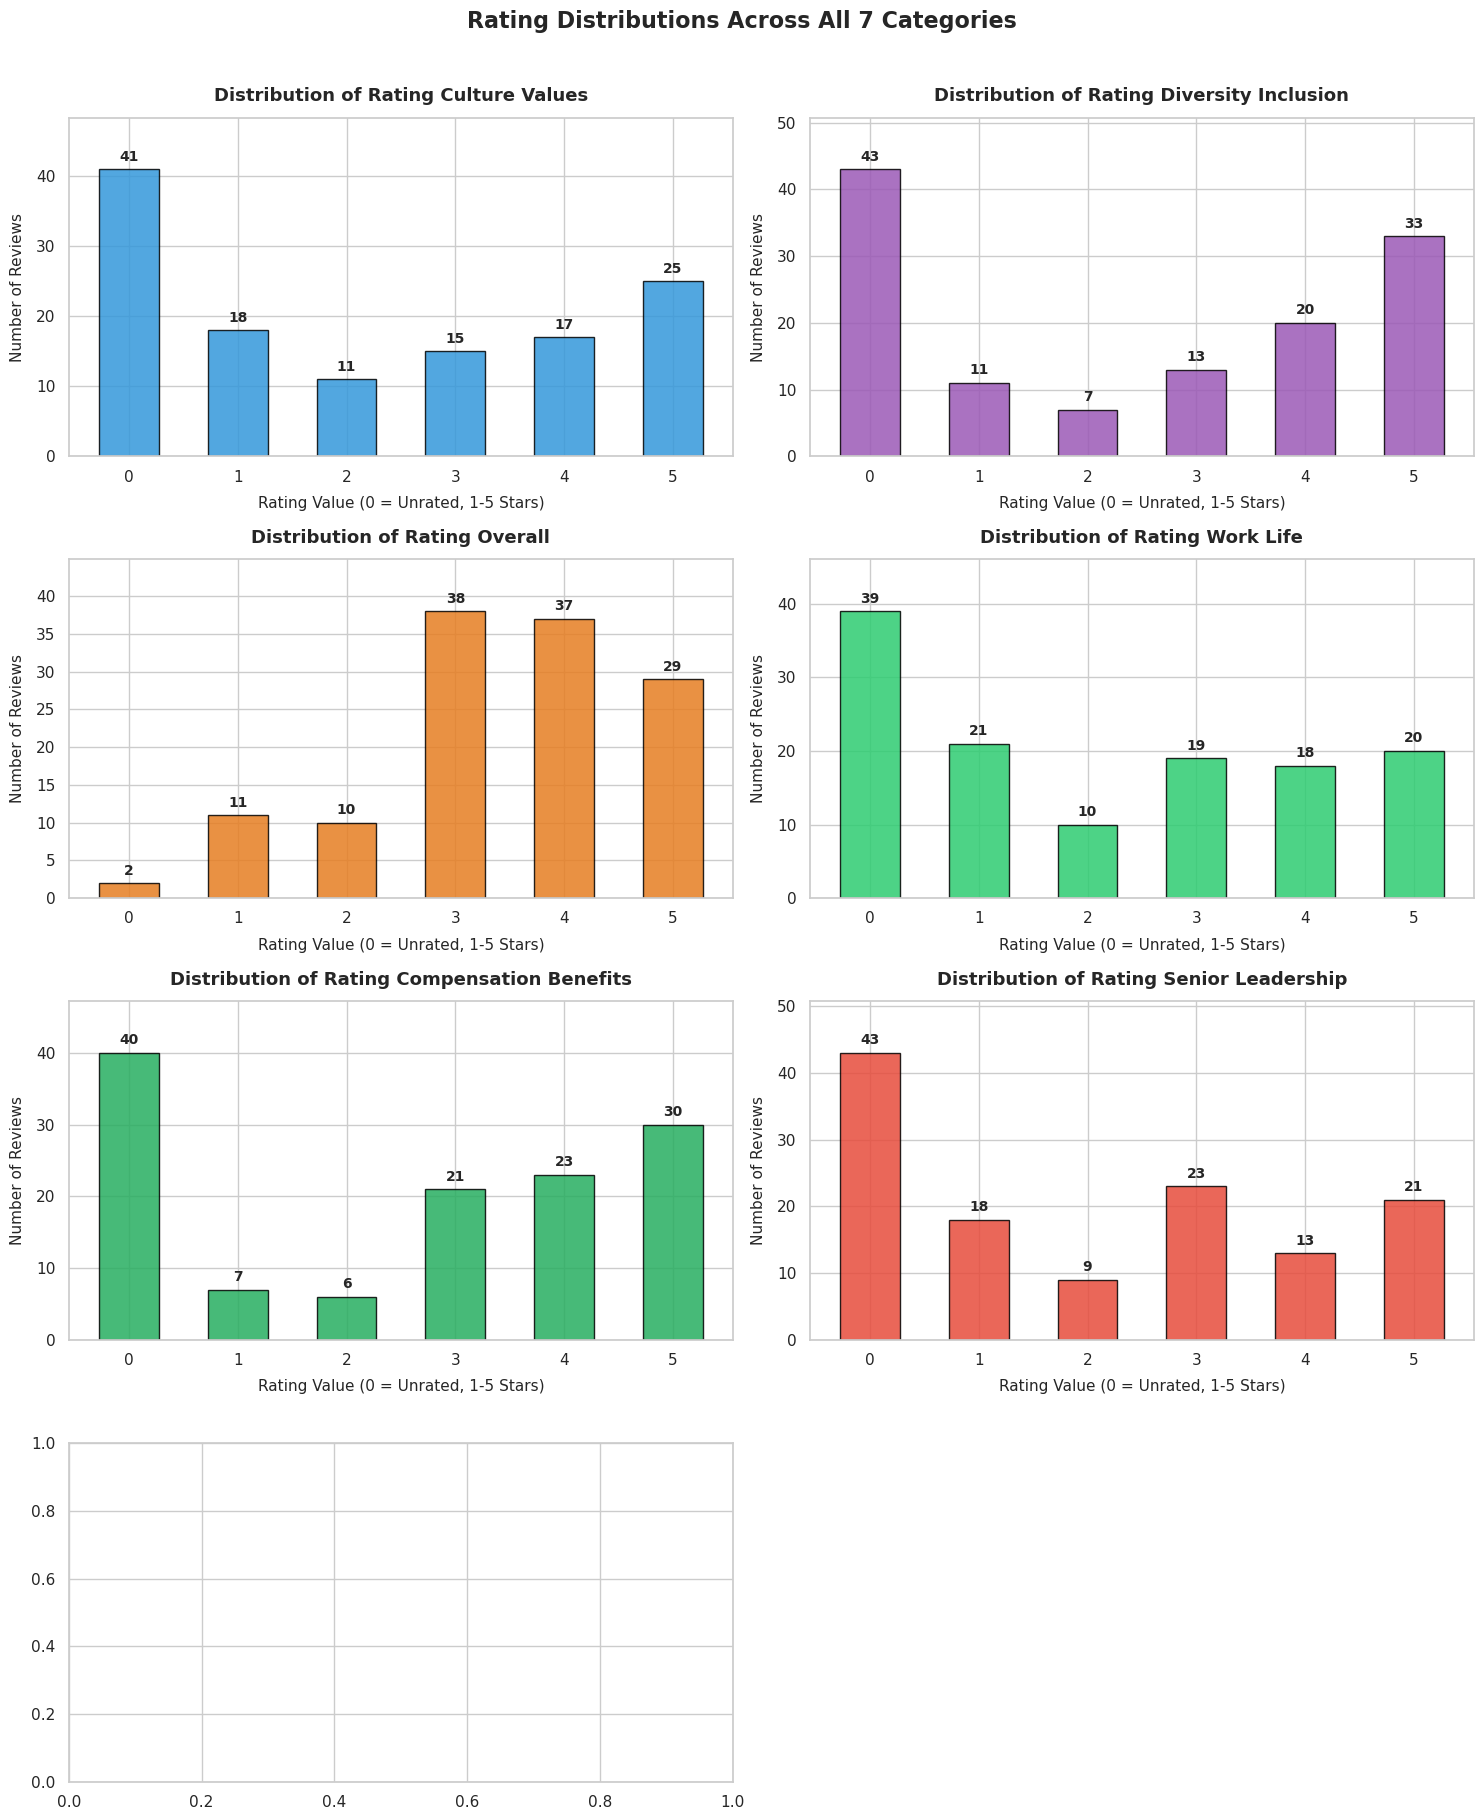

In [14]:
# Define all 7 rating columns
target_rating_cols = [
    'rating_culture_values',
    'rating_diversity_inclusion',
    'rating_overall',
    'rating_work_life',
    'rating_compensation_benefits',
    'rating_senior_leadership'
]

# Call the reusable function to display all 7 columns side-by-side in a 4x2 grid
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
colors = ['#3498db', '#9b59b6', '#e67e22', '#2ecc71', '#27ae60', '#e74c3c']

for i, col in enumerate(target_rating_cols):
    plot_rating_bar_chart(df, col, color=colors[i], exclude_zero=False, ax=axes[i])

# Hide the unused 8th subplot
axes[-1].set_visible(False)

plt.suptitle("Rating Distributions Across All 7 Categories", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Cell 6: Temporal Analysis – Review Volume by Year
**What we are exploring:**
- Converting the raw `rating_date` strings into standardized datetime objects (`pd.to_datetime` with UTC).
- Extracting the review year (`rating_year`) to evaluate sample distribution across time.
- Plotting a bar chart showing the total number of reviews submitted in 2024 vs. 2025.

=== Review Counts by Extracted Year ===
rating_year
2024.0    29
2025.0    96
NaN        2
Name: count, dtype: int64


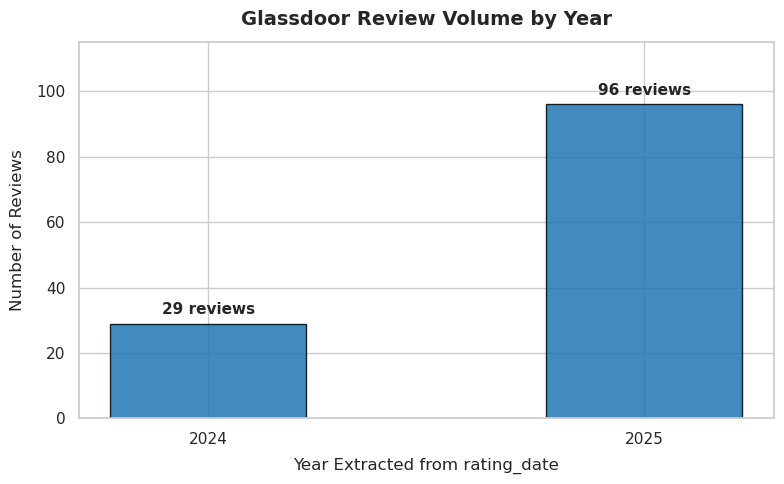

In [11]:
# 2. Extract year from rating_date and plot reviews by year
# Convert rating_date to datetime (supports ISO format and YYYY-MM-DD)
df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', utc=True)
df['rating_year'] = df['rating_date'].dt.year

print("=== Review Counts by Extracted Year ===")
year_counts = df['rating_year'].value_counts(dropna=False).sort_index()
print(year_counts)

# Plot Bar Chart for rating_date (Review Count by Year)
fig, ax = plt.subplots(figsize=(8, 5))
valid_year_counts = df['rating_year'].dropna().astype(int).value_counts().sort_index()

bars = ax.bar(
    valid_year_counts.index.astype(str),
    valid_year_counts.values,
    color='#1f77b4',
    edgecolor='black',
    alpha=0.85,
    width=0.45
)

# Annotate bar tops with exact count
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height} reviews',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title("Glassdoor Review Volume by Year", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Year Extracted from rating_date", fontsize=12, labelpad=8)
ax.set_ylabel("Number of Reviews", fontsize=12, labelpad=8)
ax.set_ylim(0, max(valid_year_counts.values) * 1.2)
plt.tight_layout()
plt.show()

### Cell 7: Yearly Trend – Average Overall Star Rating
**What we are exploring:**
- Computing the mean `rating_overall` star rating grouped by year.
- Evaluating whether employee sentiment and workplace satisfaction trended upwards or downwards between years.
- Displaying average stars formatted with a 1 to 5 scale annotation.

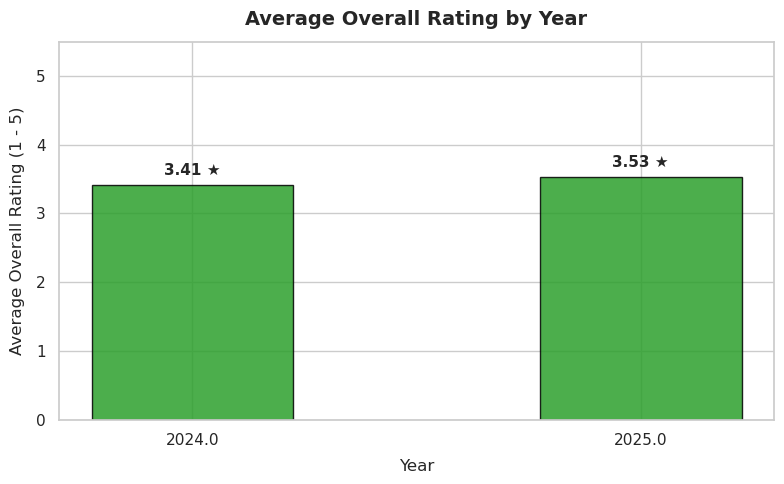

In [12]:
# Bonus Analysis: Average Overall Rating per Year
avg_by_year = df.groupby(df['rating_year'].dropna().astype(int))['rating_overall'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    avg_by_year.index.astype(str),
    avg_by_year.values,
    color='#2ca02c',
    edgecolor='black',
    alpha=0.85,
    width=0.45
)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f} ★',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_title("Average Overall Rating by Year", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Year", fontsize=12, labelpad=8)
ax.set_ylabel("Average Overall Rating (1 - 5)", fontsize=12, labelpad=8)
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()


### Cell 8: Categorical & Text Profiling (.unique() Inspection)
**What we are exploring:**
- Running `df[col].unique()` across 15 categorical, indicator, demographic, and qualitative columns to diagnose data hygiene:
  - **Helpfulness Counters:** `count_helpful`, `count_unhelpful` (checking sparsity / zeros).
  - **Tenure & Contract:** `employee_length`, `employee_status` (verifying categories and tenure in years).
  - **Employment Type:** `employee_type` (spotting plural vs. singular forms and tenure qualifiers).
  - **Binary Flags:** `flag_covid`, `flag_featured` (confirming whether these flags contain any variance or are 100% `False`).
  - **Approval & Outlook Flags:** `flags_business_outlook`, `flags_ceo_approval`, `flags_recommend_frend` (checking sentiment tags and catching typos like `'DSIAPPROVE'`).
  - **Location & Role:** `employee_location`, `employee_job_title` (inspecting domestic vs. international warehouse sites and job title consistency).
  - **Free-Form Text Feedback:** `advice_to_management`, `review_pros`, `review_cons` (checking text variety and spotting formula corruption errors like `'#NAME?'`).
- Includes an auto-load fallback to ensure the cell runs reliably even if executed immediately after a kernel restart.

In [16]:
import os
import pandas as pd

# 1. Automatically load df if it isn't in memory yet
if 'df' not in globals():
    file_path = 'data/raw/glass_reviews.csv'
    if not os.path.exists(file_path):
        file_path = '../../data/raw/glass_reviews.csv'
    df = pd.read_csv(file_path)
    if df.columns[0] != 'review_id':
        df.rename(columns={df.columns[0]: 'review_id'}, inplace=True)
    print("Loaded df successfully!")

# 2. List of target columns to inspect
columns_to_inspect = [
    'count_helpful',
    'count_unhelpful',
    'employee_length',
    'employee_status',
    'employee_type',
    'flag_covid',
    'flag_featured',
    'flags_business_outlook',
    'flags_ceo_approval',
    'flags_recommend_frend',
    'employee_location',
    'employee_job_title',
    'advice_to_management',
]

# 3. Run df[column_name].unique() across each column
for col in columns_to_inspect:
    unique_vals = df[col].unique()
    print(f"=== Column: '{col}' (Total Unique: {len(unique_vals)}) ===")
    print(unique_vals)
    print("\n" + "-" * 70 + "\n")

# drop all the unhepful columns
df.drop(columns=['count_helpful',
                'count_unhelpful',
                'rating_culture_values',
                'rating_diversity_inclusion',
                'career_opportunities_rating' ,
                'flag_covid',
                'flag_featured',
                'review_advice',
                 'company_name'])

df.columns

=== Column: 'count_helpful' (Total Unique: 1) ===
[0]

----------------------------------------------------------------------

=== Column: 'count_unhelpful' (Total Unique: 1) ===
[0]

----------------------------------------------------------------------

=== Column: 'employee_length' (Total Unique: 8) ===
[ 0  1  2  4  6  9 20  3]

----------------------------------------------------------------------

=== Column: 'employee_status' (Total Unique: 6) ===
['REGULAR' 'CONTRACT' 'PART_TIME' nan 'FREELANCE' 'INTERN']

----------------------------------------------------------------------

=== Column: 'employee_type' (Total Unique: 8) ===
['Current employee' 'Current employee, less than 1 year'
 'Current employees' 'Former employees'
 'Former employee, less than 1 year' 'Former employee' 'Former Emplpyee'
 'Former Employee']

----------------------------------------------------------------------

=== Column: 'flag_covid' (Total Unique: 1) ===
[False]

---------------------------------------

Index(['review_id', 'rating_date', 'count_helpful', 'count_unhelpful',
       'employee_length', 'employee_status', 'employee_type', 'flag_covid',
       'flag_featured', 'flags_business_outlook', 'flags_ceo_approval',
       'flags_recommend_frend', 'rating_culture_values',
       'rating_diversity_inclusion', 'rating_overall', 'rating_work_life',
       'summary', 'company_name', 'review_advice',
       'career_opportunities_rating', 'employee_location',
       'employee_job_title', 'advice_to_management', 'review_pros',
       'review_cons', 'rating_compensation_benefits',
       'rating_senior_leadership', 'rating_career_opportunities',
       'rating_year'],
      dtype='object')

## Text analyse across column
Now we have look through all the data , a simple overview of Amazon Operations Center based on the rating , we will move on with text cleaning to understand the voice of people 

Here are the few main columns that we need to inspect
1. review cons ( understand workers challenges in amazon , wgat can we do to improve them)
2. review pros ( understand why people like abot amazon ( see if it align with our observation on rating ))
3. summary - (overview of feedback on amazon )
4. advice to management - will be crucial in giving solution (backbone of our solution)

NOTE: in our previous analyst based on bar chart , we found that people are highly unsatisfied about amazon leadership and work life , we will deep diven into this section when we are reviewing the text

In [2]:
import sys
sys.path.append("..")          # so Python can find text_engine

import pandas as pd
from text_engine import TextAnalysisEngine

engine = TextAnalysisEngine(min_hits=1)

# Single column analysis
cons_result = engine.analyze_column(df, "review_cons")
print(cons_result["theme_counts"])
print(cons_result["top_words"][:10])

# Side-by-side pros vs cons
comparison = engine.compare_pros_cons(df)
comparison

ImportError: cannot import name 'clean' from 'text_engine.clean' (/Users/joanachoong/Externship/src/notebook/../text_engine/clean.py)